In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [3]:
df = pd.read_csv("data/stud (2).csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
# checking columns names
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [7]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
# check for missing values
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [9]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.columns:
    print("================================")
    print(f"Column: {col}")
    print(df[col].value_counts())

Column: gender
gender
female    518
male      482
Name: count, dtype: int64
Column: race_ethnicity
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
Column: parental_level_of_education
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
Column: lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
Column: test_preparation_course
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
Column: math_score
math_score
65    36
62    35
69    32
59    32
73    27
      ..
24     1
26     1
19     1
23     1
8      1
Name: count, Length: 81, dtype: int64
Column: reading_score
reading_score
72    34
74    33
64    32
73    30
67    30
      ..
17     1
26     1
28     1
23     1
40     1
Name: count, Length: 72, dtype: int

In [11]:
numeric_col=[feature for feature in df.columns if df[feature].dtype != 'str']
categorical_col=[feature for feature in df.columns if df[feature].dtype == 'str']

In [12]:
print( numeric_col)
print( categorical_col)

['math_score', 'reading_score', 'writing_score']
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


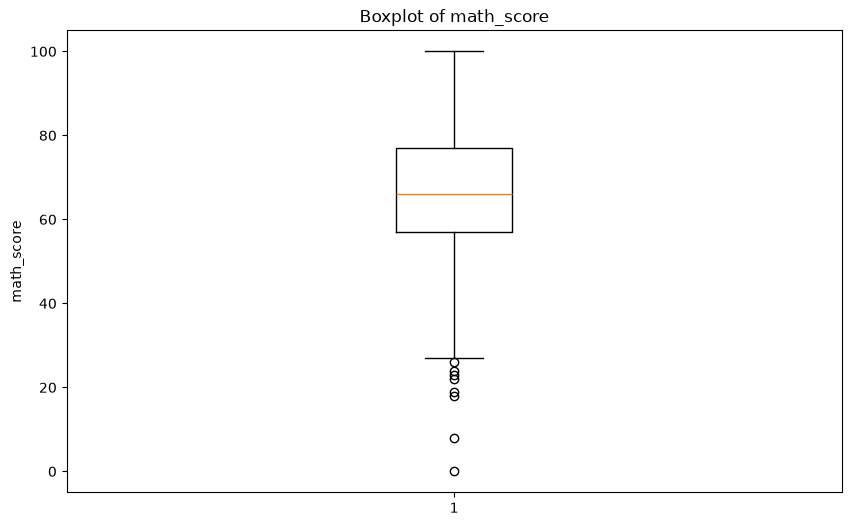

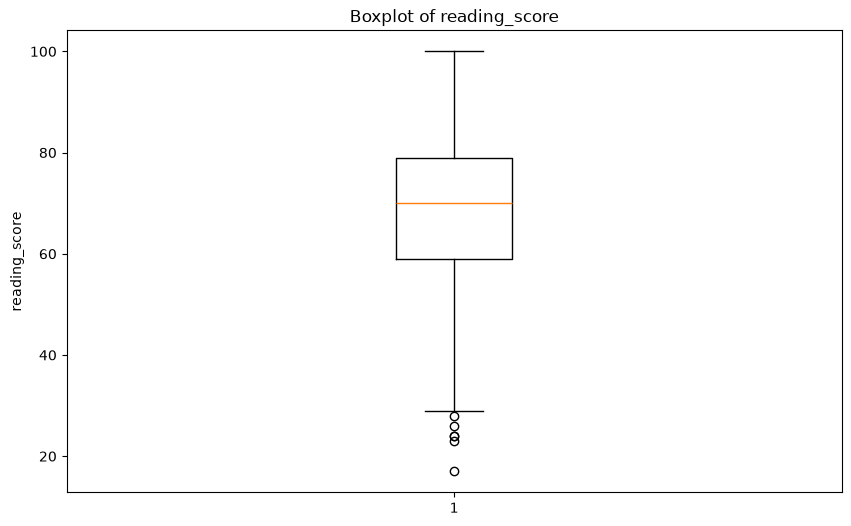

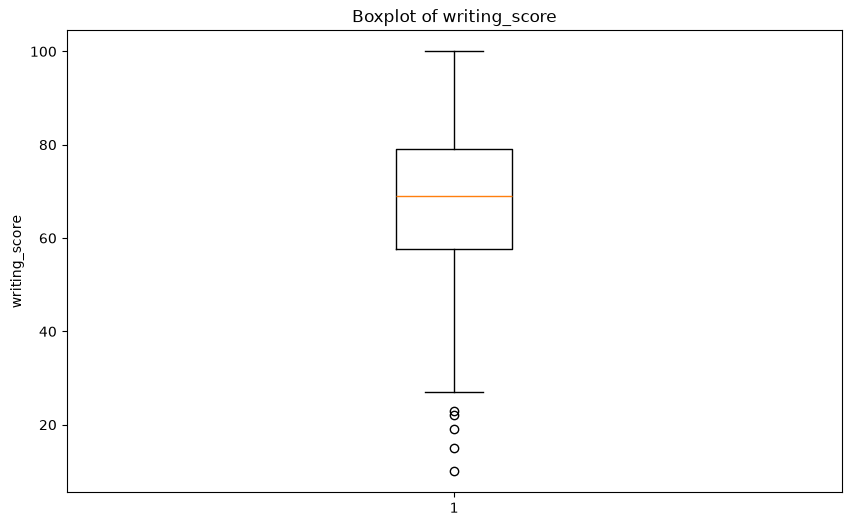

In [13]:
# check for outliers in numerical columns using boxplots

for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        plt.figure(figsize=(10, 6))
        plt.boxplot(df[col])
        plt.title(f'Boxplot of {col}')
        plt.ylabel(col)
        plt.show()

In [14]:
#  removing outliers from numerical columns using IQR method
# for col in df.columns:
#     if df[col].dtype in ['int64', 'float64']:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
#          df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [15]:
#student who score 100 in reading, math, and writing
reading_full=df[df['reading_score'] ==100]['lunch'].count()
math_full=df[df['math_score'] ==100]['lunch'].count()
writing_full=df[df['writing_score'] ==100]['lunch'].count()
print(f"Number of students who scored 100 in reading: {reading_full}")
print(f"Number of students who scored 100 in math: {math_full}")
print(f"Number of students who scored 100 in writing: {writing_full}")

Number of students who scored 100 in reading: 17
Number of students who scored 100 in math: 7
Number of students who scored 100 in writing: 14


In [16]:
#students who scored 20 or less in reading, math, and writing
reading_full=df[df['reading_score'] <=20 ]['lunch'].count()
math_full=df[df['math_score'] <=20 ]['lunch'].count()
writing_full=df[df['writing_score'] <=20 ]['lunch'].count()
print(f"Number of students who scored 20 or less in reading: {reading_full}")
print(f"Number of students who scored 20 or less in math: {math_full}")
print(f"Number of students who scored 20 or  in writing: {writing_full}")

Number of students who scored 20 or less in reading: 1
Number of students who scored 20 or less in math: 4
Number of students who scored 20 or  in writing: 3


In [17]:
df['Total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['Average_score'] = df['Total_score'] / 3

In [18]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [19]:
df.groupby('gender')['Average_score'].count()

gender
female    518
male      482
Name: Average_score, dtype: int64

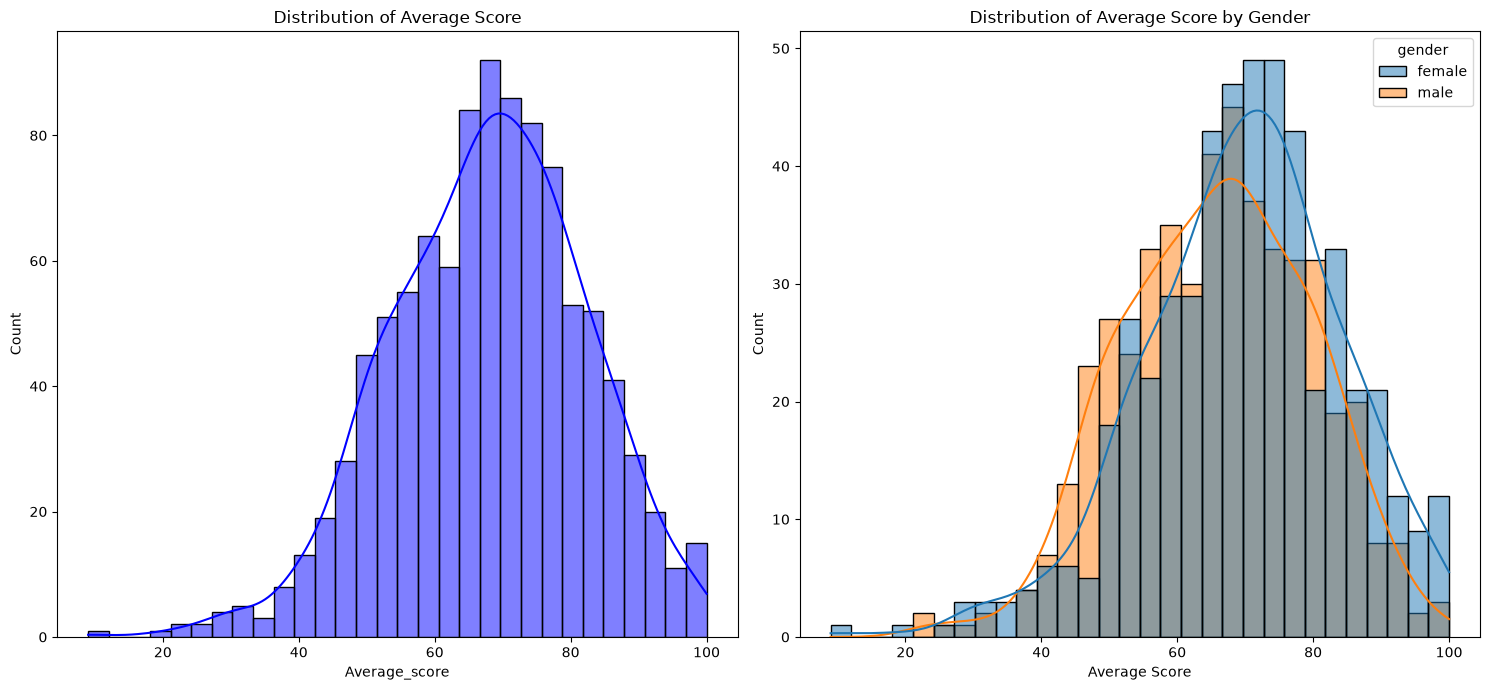

In [20]:
plt.subplots(1, 2, figsize=(15,7))
plt.subplot(121)
sns.histplot(df['Average_score'], kde=True, color='blue',bins=30)
plt.title('Distribution of Average Score')

plt.subplot(122)
sns.histplot(data=df, x='Average_score', hue='gender', kde=True, bins=30)
plt.title('Distribution of Average Score by Gender')
plt.xlabel('Average Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

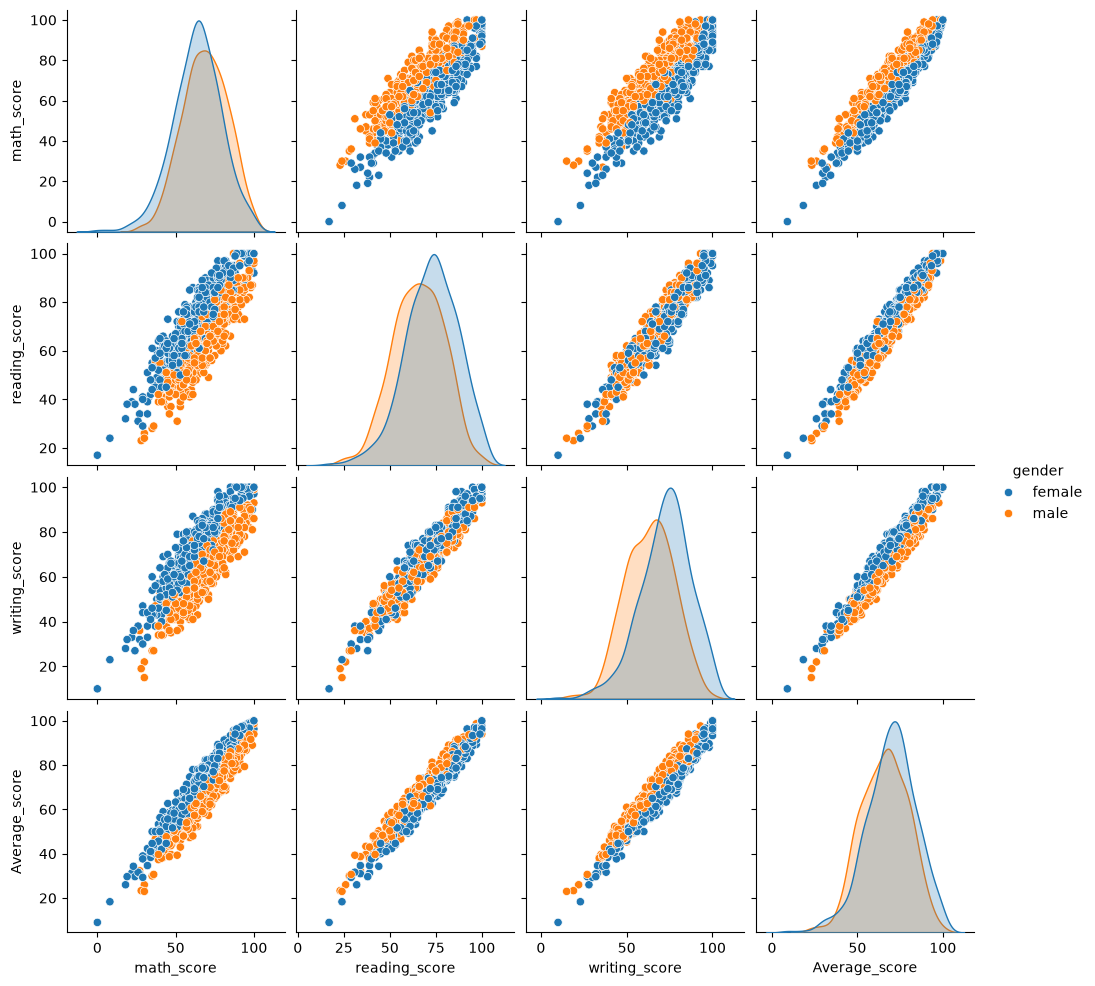

In [21]:
sns.pairplot(df, hue='gender', vars=['math_score', 'reading_score', 'writing_score', 'Average_score'])  

student count who got full mark in subject 


In [22]:
reading_full=df[df['reading_score'] == 100]['lunch'].count()
reading_full

np.int64(17)

In [23]:
#on the basis of lunch type avg score of women and men
avg_reading=df.groupby('lunch')['reading_score'].mean()
avg_math=df.groupby('lunch')['math_score'].mean()
avg_writing=df.groupby('lunch')['writing_score'].mean()
print("Average Scores by Lunch Type:")
print(avg_reading)
print(avg_math)
print(avg_writing)


Average Scores by Lunch Type:
lunch
free/reduced    64.653521
standard        71.654264
Name: reading_score, dtype: float64
lunch
free/reduced    58.921127
standard        70.034109
Name: math_score, dtype: float64
lunch
free/reduced    63.022535
standard        70.823256
Name: writing_score, dtype: float64


In [27]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


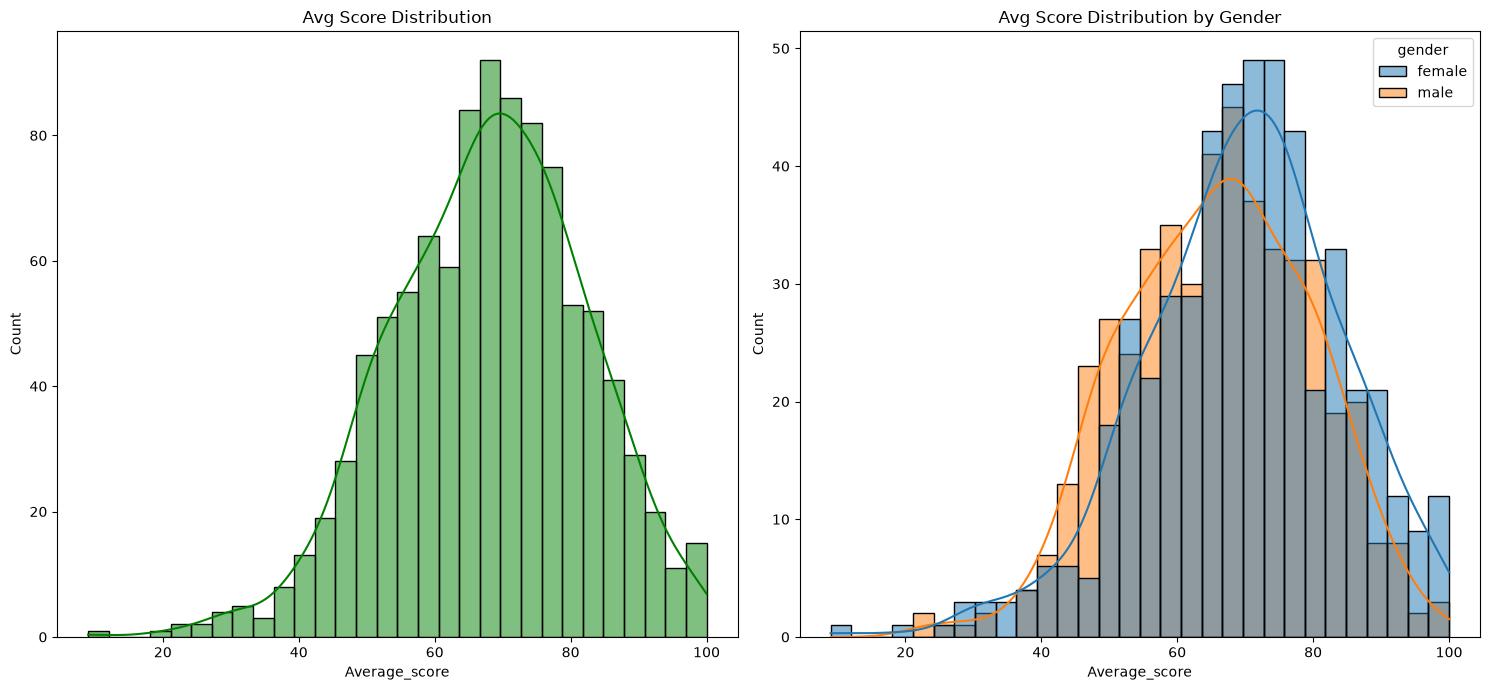

In [42]:
plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average_score',kde=True,bins=30,color='green')
plt.title('Avg Score Distribution')
plt.subplot(122)
sns.histplot(data=df,x='Average_score',kde=True,bins=30,color='green',hue='gender')
plt.title('Avg Score Distribution by Gender')
plt.tight_layout()
plt.show()

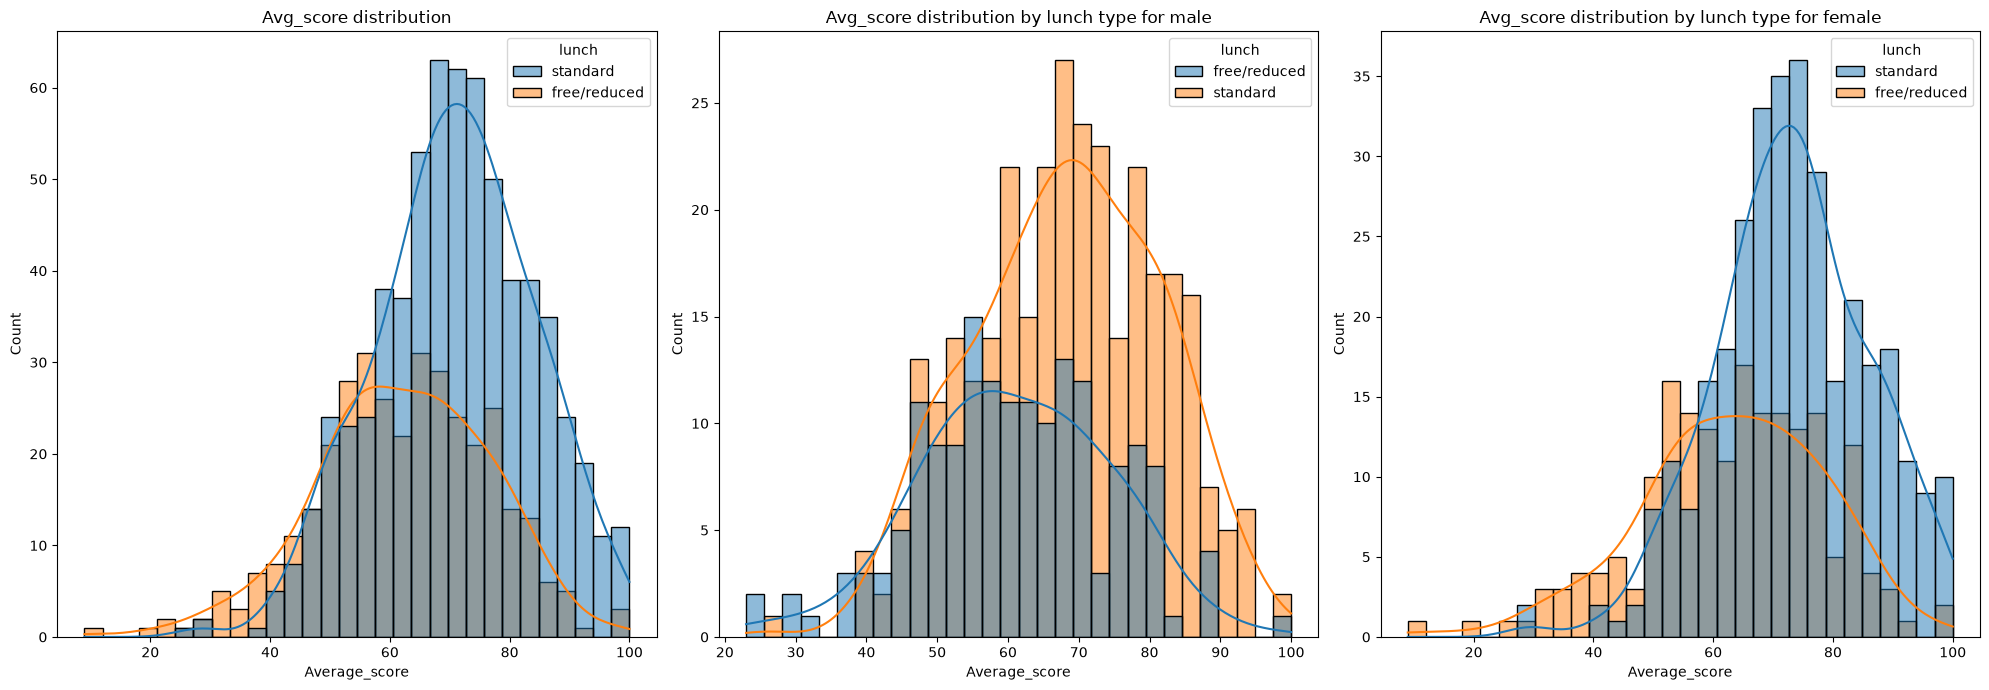

In [43]:
plt.subplots(1, 3, figsize=(20, 7))
plt.subplot(131)
sns.histplot(data=df,x='Average_score',kde=True,bins=30,color='green',hue='lunch')
plt.title('Avg_score distribution')

plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='Average_score',kde=True,bins=30,color='yellow',hue='lunch')
plt.title('Avg_score distribution by lunch type for male')

plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='Average_score',kde=True,bins=30,color='blue',hue='lunch')
plt.title('Avg_score distribution by lunch type for female')
plt.tight_layout()
plt.show()